In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

2026-03-01 23:59:29.356060: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
PROJECT_ROOT = Path().resolve().parent

MODEL_PATH = PROJECT_ROOT / "models" / "deblur_model1.h5"

model = load_model(MODEL_PATH, compile=False)

In [4]:
def apply_blur(image):
    image_tf = tf.convert_to_tensor(image[None, ...])
    
    kernel = tf.ones((5, 5, 3, 1)) / 25.0
    
    blurred = tf.nn.depthwise_conv2d(
        image_tf,
        kernel,
        strides=[1,1,1,1],
        padding="SAME"
    )
    
    return blurred[0].numpy()

In [ ]:
IMG_SIZE = 128

def process_and_predict(image_path):
    
    # cargar y redimensionar
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img).astype("float32") / 255.0
    
    # aplicar blur
    blurred = apply_blur(img)
    
    # predicción
    pred = model.predict(blurred[None, ...])[0]
    
    return img, blurred, pred

In [6]:
def show_comparison(original, blurred, predicted):
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.imshow(blurred)
    plt.title("Blurred (Input)")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.imshow(predicted)
    plt.title("Deblurred (Model)")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

1/1 [==============================] - 0s 341ms/step


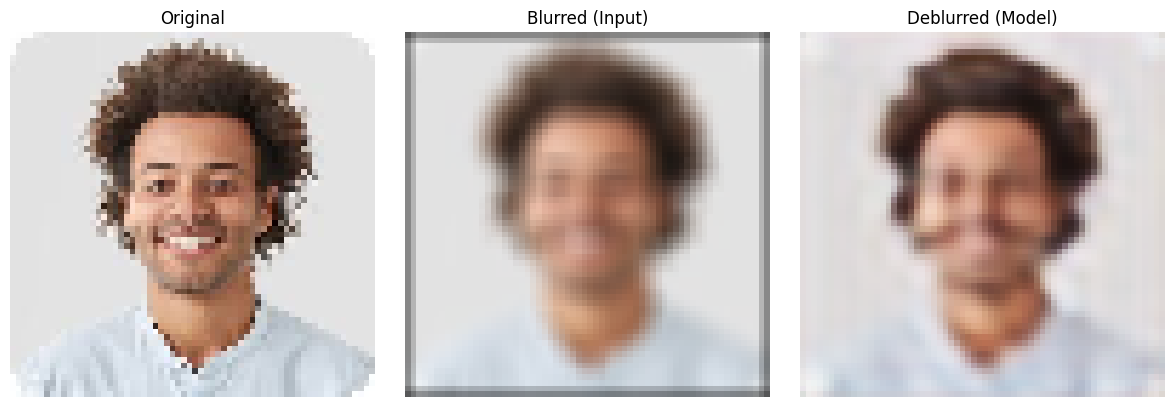

In [9]:
image_path = "../tests/images.jpeg"

original, blurred, predicted = process_and_predict(image_path)

show_comparison(original, blurred, predicted)

In [ ]:
# para meter una imagen ya borrosa

def compare_blur_vs_output(model, image_path, img_size=128):

    # cargar imagen
    img = tf.keras.utils.load_img(image_path)
    img_array = tf.keras.utils.img_to_array(img)

    # redimensionar
    img_resized = tf.image.resize(img_array, (img_size, img_size))

    # normalizar (igual que en el train)
    img_normalized = img_resized / 255.0
    input_img = tf.expand_dims(img_normalized, axis=0)

    # predicción
    pred = model.predict(input_img, verbose=0)[0]
    pred = tf.clip_by_value(pred, 0, 1)

    # ver la comparación
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Input Borrosa")
    plt.imshow(img_resized.numpy().astype("uint8"))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Output Deblur")
    plt.imshow(pred)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return pred

In [ ]:
image_path1 = "../tests/images4.png"
compare_blur_vs_output(model, image_path1, img_size=128)